
First 10 Records
   Price  Promotion  Holiday  Demand
0    152          1        1     953
1    142          0        0     525
2     64          0        1     908
3    156          0        0     529
4    121          0        1     748
5     70          0        1     958
6    152          0        1     680
7    171          1        1     868
8    124          0        0     586
9    137          0        1     787

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Price      100 non-null    int64
 1   Promotion  100 non-null    int64
 2   Holiday    100 non-null    int64
 3   Demand     100 non-null    int64
dtypes: int64(4)
memory usage: 3.3 KB
None

Statistical Summary
            Price  Promotion     Holiday       Demand
count  100.000000  100.00000  100.000000   100.000000
mean   119.950000    0.43000    0.520000   824.6300

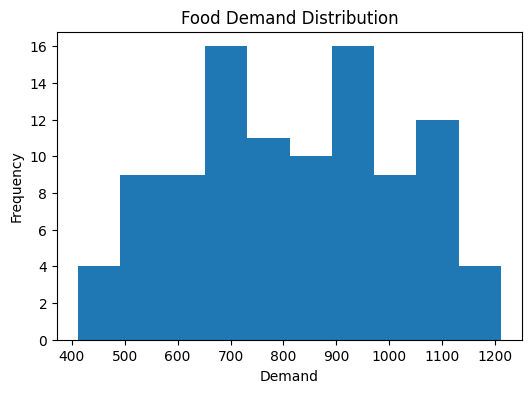

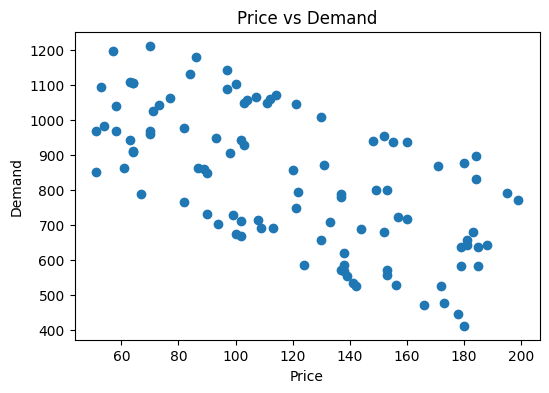


Model Performance
MAE : 27.85655045981516
R2 Score : 0.9706661626666357

Predicted Future Food Demand:
886.58


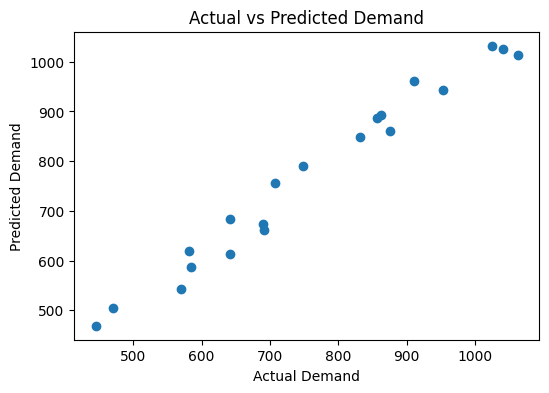

In [2]:
# ==========================================
# FOOD DEMAND FORECASTING SYSTEM
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# ------------------------------------------
# Generate Dataset
# ------------------------------------------

np.random.seed(42)

n = 100

price = np.random.randint(50, 200, n)
promotion = np.random.randint(0, 2, n)
holiday = np.random.randint(0, 2, n)

demand = (
    1000
    - (price * 3)
    + (promotion * 250)
    + (holiday * 150)
    + np.random.randint(-50, 50, n)
)

data = pd.DataFrame({
    "Price": price,
    "Promotion": promotion,
    "Holiday": holiday,
    "Demand": demand
})

print("\nFirst 10 Records")
print(data.head(10))

# ------------------------------------------
# Data Analysis
# ------------------------------------------

print("\nDataset Information")
print(data.info())

print("\nStatistical Summary")
print(data.describe())

# ------------------------------------------
# Visualization
# ------------------------------------------

plt.figure(figsize=(6,4))
plt.hist(data["Demand"], bins=10)
plt.title("Food Demand Distribution")
plt.xlabel("Demand")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(data["Price"], data["Demand"])
plt.title("Price vs Demand")
plt.xlabel("Price")
plt.ylabel("Demand")
plt.show()

# ------------------------------------------
# Prepare Data
# ------------------------------------------

X = data[["Price", "Promotion", "Holiday"]]
y = data["Demand"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ------------------------------------------
# Train Model
# ------------------------------------------

model = LinearRegression()
model.fit(X_train, y_train)

# ------------------------------------------
# Prediction
# ------------------------------------------

y_pred = model.predict(X_test)

# ------------------------------------------
# Evaluation
# ------------------------------------------

print("\nModel Performance")
print("MAE :", mean_absolute_error(y_test, y_pred))
print("R2 Score :", r2_score(y_test, y_pred))

# ------------------------------------------
# Future Demand Forecast
# ------------------------------------------

new_food = pd.DataFrame({
    "Price": [120],
    "Promotion": [1],
    "Holiday": [0]
})

future_demand = model.predict(new_food)

print("\nPredicted Future Food Demand:")
print(round(future_demand[0], 2))

# ------------------------------------------
# Actual vs Predicted
# ------------------------------------------

plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")
plt.title("Actual vs Predicted Demand")
plt.show()